# AnomaLens — End-to-End Demo

> Infrastructure log analysis with RAG-based root cause analysis  
> GitHub: https://github.com/hasla2/AnomaLens

**Pipeline overview:**
1. Collect logs from Graylog every 15 min
2. Normalize templates: `<HOST>`, `<IP>`, `<NUM>`
3. Classify with TF-IDF + LinearSVC (macro F1 = 0.987)
4. RAG explanation for errors: all-MiniLM-L6-v2 + Phi-3.5-Mini
5. Daily summary: Mistral-7B

> **Prerequisites:** Run from project root with venv activated:  
> `venv\Scripts\activate && pip install -r requirements.txt`

In [5]:
# pip install --user matplotlib scikit-learn
import json, glob, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# ── Constants (same as evaluate.py) ──────────────────────────────────────────
ALL_LABELS   = ['noise', 'important', 'error', 'security_noise']
SEARCH_ORDER = ['security_noise', 'error', 'important', 'noise']
RANDOM_STATE = 42
TEST_SIZE    = 0.2
OOD_THRESHOLD = 0.45

print('Setup complete ✓')

Setup complete ✓


## 1. Dataset Exploration

64,744 anonymized log templates collected from VMware ESXi and Hyper-V clusters via Graylog.  
All hostnames → `<HOST>`, IPs → `<IP>`, numbers → `<NUM>`.

In [6]:
df = pd.read_csv('data/labels/labels.csv')
df = df[df['label'].isin(ALL_LABELS)].reset_index(drop=True)

print(f'Total templates : {len(df):,}')
print(f'Columns         : {list(df.columns)}')
df.head()

Total templates : 64,744
Columns         : ['template', 'label', 'event_type', 'service', 'platform', 'count', 'label_confidence', 'label_candidates']


,template,label,event_type,service,platform,count,label_confidence,label_candidates
0,the access history in hive \??\c:\programdata\...,security_noise,registry_activity,QualysAgent,hyperv,140314,1.000,"{""security_noise"": 140314}"
1,<HOST> envoy-access[<NUM>]: post /sdk <NUM> vi...,noise,api_request,envoy-access,esxi,119228,0.981,"{""noise"": 116974, ""error"": 2254}"
2,the start type of the background intelligent t...,noise,service_config_change,Background Intelligent Transfer Service,hyperv,32249,1.000,"{""noise"": 32249}"
3,the background intelligent transfer service se...,noise,other,Background Intelligent Transfer Service,hyperv,29034,1.000,"{""noise"": 29034}"
4,<HOST> sdrsinjector[<NUM>]: slope info history...,noise,other,sdrsInjector,esxi,18085,1.000,"{""noise"": 18085}"


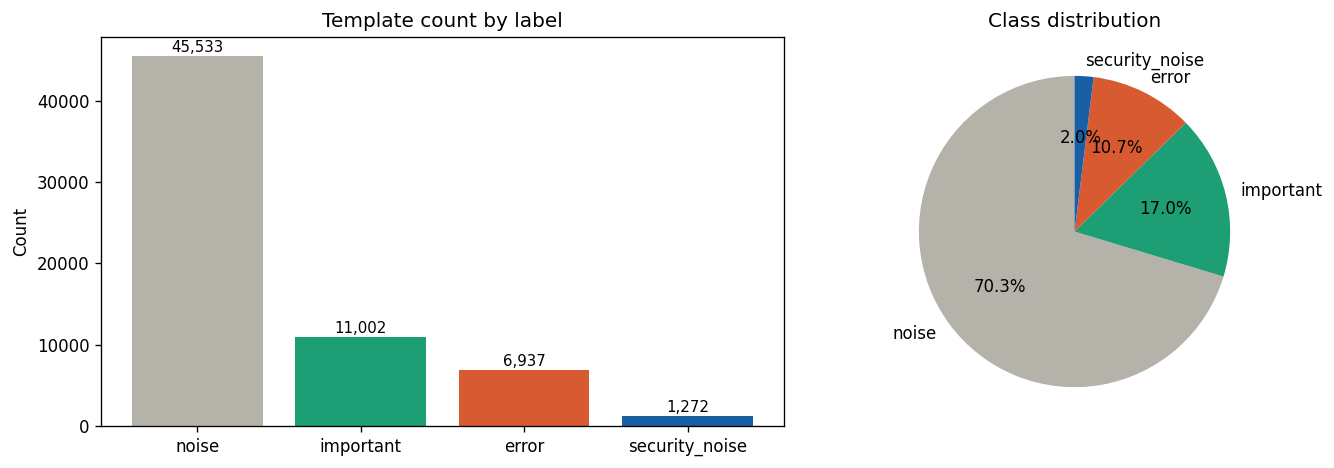

label
noise             45533
important         11002
error              6937
security_noise     1272


In [7]:
counts       = df['label'].value_counts()
labels_order = ['noise','important','error','security_noise']
values       = [counts.get(l, 0) for l in labels_order]
colors       = ['#B4B2A9','#1D9E75','#D85A30','#185FA5']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels_order, values, color=colors)
axes[0].set_title('Template count by label')
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v + 400, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(values, labels=labels_order, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class distribution')

plt.tight_layout()
plt.show()
print(counts.to_string())

In [8]:
# Sample templates per class
for label in ALL_LABELS:
    sample = df[df['label'] == label]['template'].head(3).tolist()
    print(f'\n--- {label.upper()} ---')
    for t in sample:
        print(f'  {t[:120]}')


--- NOISE ---
  <HOST> envoy-access[<NUM>]: post /sdk <NUM> via_upstream - <NUM> <NUM> gzip <NUM> <NUM> <NUM> <IP>:<NUM> http/<NUM>.<NUM
  the start type of the background intelligent transfer service se
  the background intelligent transfer service service entered the

--- IMPORTANT ---
  <HOST> hostd[<NUM>]: [originator@<NUM> sub=vmxstatsprovider(<ID>).vmxstats(<NUM>)] ~statsfilereader: statsfilereader des
  <HOST> vpxa[<NUM>]: [originator@<NUM> sub=vpxlro opid=<ID>] [vpxlro] -- finish task-<NUM>
  <HOST> healthdplugins[<NUM>]: - time the service was last started <TIMESTAMP>, section for vmware esxi, pid=<NUM>, versi

--- ERROR ---
  <HOST> sandboxd[<NUM>]: [originator@<NUM> sub=default.httpservice.httpconnection] http connection has timed out while wa
  <HOST> hostd[<NUM>]: [originator@<NUM> sub=libs opid=<ID> sid=<ID> user=vpxuser:vsphere.local\vpxd-extension-<UUID>] not
  <HOST> hostd[<NUM>]: [originator@<NUM> sub=libs opid=<ID> sid=<ID> user=vpxuser:vsphere.local\vpxd-extension-

## 2. Template Normalization

Raw log messages are normalized into semantic templates by replacing variable fields with typed placeholders.

In [18]:
try:
    from src.collector.normalizer import normalize_template, normalize_hosts
    NORMALIZER_OK = True
except ImportError:
    print('normalizer.py not found — showing example output only')
    NORMALIZER_OK = False

examples = [
    'cluster_host-33-2.domain.com hostd[2097551]: failed to connect to vpxa: connection refused',
    'cluster_host-61-1.domain.com vmkernel: cpu3:2097551 nmp: error status h:0x4319192910c90',
    'vpxuser login from 127.0.0.1',
    'cluster_host-41-2.domain.com Vpxa: task a7b234d4-e5f6-7890-abcd-ef12345567890 completed',
    'cluster_host-33-1.domain.com sdrsInjector[2098700]: opening slot count file /vmfs/volumes//vSAN/file',
]

print(f'{"Raw message":55} → Template')
print('-' * 115)
for msg in examples:
    if NORMALIZER_OK:
        tmpl = normalize_template(normalize_hosts(msg))
    else:
        tmpl = '<HOST> hostd[<NUM>]: failed to connect to vpxa: connection refused'
    print(f'{msg[:55]:<55} → {tmpl[:80]}')

Raw message                                             → Template
-------------------------------------------------------------------------------------------------------------------
cluster_host-33-2.domain.com hostd[2097551]: failed to  → <HOST> hostd[<NUM>]: failed to connect to vpxa: connection refused
cluster_host-61-1.domain.com vmkernel: cpu3:2097551 nmp → <HOST> vmkernel: cpu<NUM>:<NUM> nmp: error status h:<HEX>
vpxuser login from 127.0.0.1                            → vpxuser login from <IP>
cluster_host-41-2.domain.com Vpxa: task a7b234d4-e5f6-7 → <HOST> vpxa: task <UUID> completed
cluster_host-33-1.domain.com sdrsInjector[2098700]: ope → <HOST> sdrsinjector[<NUM>]: opening slot count file /vmfs/volumes//<DATASTORE>/f


## 3. Load Pre-trained Classifiers

All four classifiers use TF-IDF (1,2)-grams + `class_weight='balanced'`.  
Run `python train_model.py` first to generate model files.

In [19]:
MODELS_DIR = Path('models')
MODEL_FILES = {
    'Naive Bayes':   'naive_bayes.joblib',
    'Random Forest': 'random_forest.joblib',
    'LogReg':        'logreg.joblib',
    'LinearSVC':     'linearsvc.joblib',
}

X_train, X_test, y_train, y_test = train_test_split(
    df['template'].tolist(), df['label'].tolist(),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df['label']
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

results = []
for name, fname in MODEL_FILES.items():
    path = MODELS_DIR / fname
    if not path.exists():
        print(f'  MISSING: {path} — run train_model.py first')
        continue
    pipe   = joblib.load(path)
    y_pred = pipe.predict(X_test)
    macro  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_err = f1_score(y_test, y_pred, labels=['error'],          average='micro', zero_division=0)
    f1_sec = f1_score(y_test, y_pred, labels=['security_noise'], average='micro', zero_division=0)
    acc    = float(np.mean(np.array(y_test) == np.array(y_pred)))
    results.append({'Model': name, 'Accuracy': round(acc,4),
                    'Macro F1': round(macro,4), 'F1 error': round(f1_err,4),
                    'F1 sec_n': round(f1_sec,4)})
    print(f'  {name:<15}  macro F1={macro:.4f}')

results_df = pd.DataFrame(results)
results_df

Train: 51,795  |  Test: 12,949
  Naive Bayes      macro F1=0.8835
  Random Forest    macro F1=0.9594
  LogReg           macro F1=0.9746
  LinearSVC        macro F1=0.9868


,Model,Accuracy,Macro F1,F1 error,F1 sec_n
0,Naive Bayes,0.9171,0.8835,0.9377,0.8582
1,Random Forest,0.9863,0.9594,0.9659,0.8911
2,LogReg,0.9907,0.9746,0.9731,0.9387
3,LinearSVC,0.9937,0.9868,0.9783,0.9780


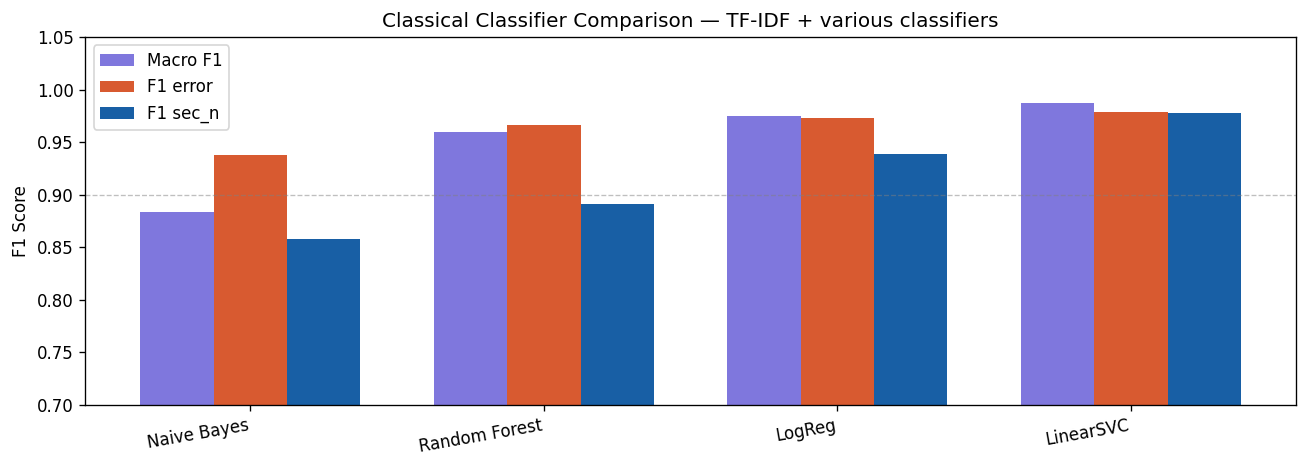

In [20]:
if not results_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    x = np.arange(len(results_df))
    w = 0.25
    ax.bar(x - w, results_df['Macro F1'], w, label='Macro F1',  color='#7F77DD')
    ax.bar(x,     results_df['F1 error'], w, label='F1 error',  color='#D85A30')
    ax.bar(x + w, results_df['F1 sec_n'], w, label='F1 sec_n',  color='#185FA5')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=10, ha='right')
    ax.set_ylim(0.7, 1.05)
    ax.set_ylabel('F1 Score')
    ax.set_title('Classical Classifier Comparison — TF-IDF + various classifiers')
    ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Classification Demo — LinearSVC

Default model uses `decision_function` with softmax normalization as confidence proxy.  
Templates with confidence < 0.45 are flagged as **anomaly** (OOD detection).

In [21]:
prod_model = joblib.load('model.joblib')

RISK_SCORE = {'noise':0,'security_noise':1,'important':7,'error':10,'anomaly':15}

def classify(template):
    scores     = prod_model.decision_function([template])[0]
    best_idx   = scores.argmax()
    pred       = prod_model.classes_[best_idx]
    exp_scores = np.exp(scores - scores.max())
    confidence = float(exp_scores[best_idx] / exp_scores.sum())
    if confidence < OOD_THRESHOLD:
        pred = 'anomaly'
    return {'label': pred, 'confidence': round(confidence, 3),
            'risk': RISK_SCORE.get(pred, 0)}

test_cases = [
    '<host> hostd[<num>]: failed to connect to vpxa: connection refused',
    '<host> sdrsinjector[<num>]: opening slot count file /vmfs/volumes//<datastore>/.naa.<id>/slotsfile',
    'vpxuser login from <ip>',
    '<host> vmms[<num>]: virtual machine powered on',
    '<host> vmkernel: completely unknown xyz event pattern abc 999 zxcv',
]

print(f'{"Template":<72} {"Label":<16} {"Conf":<6} Risk')
print('-' * 108)
for t in test_cases:
    r = classify(t)
    flag = '  ← OOD anomaly' if r['label'] == 'anomaly' else ''
    print(f'{t[:72]:<72} {r["label"]:<16} {r["confidence"]:<6} {r["risk"]}{flag}')

Template                                                                 Label            Conf   Risk
------------------------------------------------------------------------------------------------------------
<host> hostd[<num>]: failed to connect to vpxa: connection refused       error            0.863  10
<host> sdrsinjector[<num>]: opening slot count file /vmfs/volumes//<data noise            0.748  0
vpxuser login from <ip>                                                  noise            0.527  0
<host> vmms[<num>]: virtual machine powered on                           noise            0.659  0
<host> vmkernel: completely unknown xyz event pattern abc 999 zxcv       noise            0.59   0


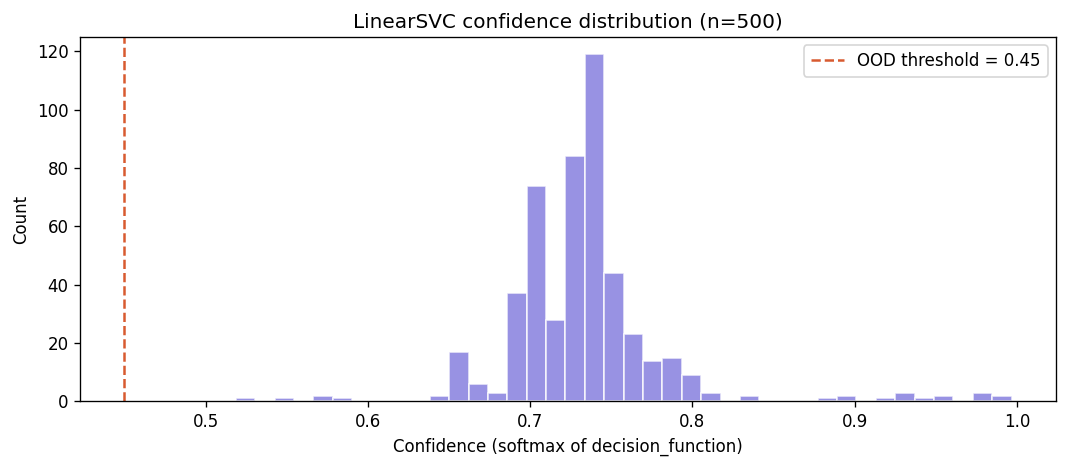

OOD rate     : 0.0%  (confidence < 0.45)
Mean conf    : 0.734 ± 0.051


In [22]:
# Confidence distribution — 500 random templates
sample500 = df.sample(500, random_state=42)
confs = []
for tmpl in sample500['template']:
    scores     = prod_model.decision_function([tmpl])[0]
    exp_scores = np.exp(scores - scores.max())
    confs.append(float(exp_scores.max() / exp_scores.sum()))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(confs, bins=40, color='#7F77DD', alpha=0.8, edgecolor='white')
ax.axvline(OOD_THRESHOLD, color='#D85A30', linestyle='--',
           linewidth=1.5, label=f'OOD threshold = {OOD_THRESHOLD}')
ax.set_xlabel('Confidence (softmax of decision_function)')
ax.set_ylabel('Count')
ax.set_title('LinearSVC confidence distribution (n=500)')
ax.legend()
plt.tight_layout()
plt.show()

ood_pct = sum(c < OOD_THRESHOLD for c in confs) / len(confs) * 100
print(f'OOD rate     : {ood_pct:.1f}%  (confidence < {OOD_THRESHOLD})')
print(f'Mean conf    : {np.mean(confs):.3f} ± {np.std(confs):.3f}')

## 5. RAG Root Cause Analysis

When an error or anomaly is detected:
1. **all-MiniLM-L6-v2** encodes the template → 384-dim vector
2. **Qdrant** cosine search finds top-3 relevant doc chunks from VMware/Hyper-V docs
3. **Phi-3.5-Mini** (via Ollama) generates a natural-language explanation

> **Requires:** `python src/rag/indexer.py` + `ollama serve`

In [23]:
RAG_AVAILABLE = Path('data/qdrant').exists()

if RAG_AVAILABLE:
    from src.rag.retriever import RAGRetriever
    rag     = RAGRetriever()
    anomaly = '<host> hostd[<num>]: failed to connect to vpxa: connection refused'

    print(f'Anomaly: {anomaly}\n')
    chunks = rag.search(anomaly)
    print('Top-3 retrieved documentation chunks:')
    for i, c in enumerate(chunks, 1):
        print(f'\n[{i}] score={c["score"]} | {c["platform"]}')
        print(f'    {c["text"][:200]}...')

    print('\nGenerating explanation (Phi-3.5-Mini)...')
    result = rag.explain(anomaly)
    print(f'\nEXPLANATION:\n{result["explanation"]}')
else:
    print('Qdrant not indexed. Run: python src/rag/indexer.py')
    print('\nExample output from previous run:')
    print('  score=0.461 | vmware')
    print('  Explanation: The VPXA service is not running on the ESXi host.')
    print('  Check service status; verify firewall rules for ports 49012-50638.')

Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6021.43it/s]


Qdrant: 1009 chunks
Anomaly: <host> hostd[<num>]: failed to connect to vpxa: connection refused

Top-3 retrieved documentation chunks:

[1] score=0.461 | vmware
    WARE_CIS_HOME%"\vmafdd\vecs-cli entry list --store data-encipherment --text | egrep 'Alias|Serial Number:|Subject:|Not Before|Not After'
Stop VPXD, run the Windows Customization Key update, then start...

[2] score=0.416 | vmware
    ult, ESXi hosts might briefly become unresponsive, and you see a
directory. The vpxa logs contain the line
Workaround: None. The vpxa service automatically restarts and corrects the issue.
You see an ...

[3] score=0.416 | vmware
    configuration option is added under the name
vmacore/soap/enableSessionTimeoutPenalties
. Setting this boolean option to "false" will disable the new functionality and this should resolve the issue. T...

Generating explanation (Phi-3.5-Mini)...

EXPLANATION:
 The log entry indicates that there was a failure when attempting to connect to vpxa (presumably VPXA servi

## 6. Mistral-7B Zero-shot Classification

Mistral-7B-Instruct with few-shot prompting and one-word output format.  
Evaluated on stratified sample (50 per class).

> **Requires:** `ollama serve` + `ollama create mistral7b -f Modelfile7b`

In [25]:
import os, time

MISTRAL_PROMPT = """\
You are a log classifier. Reply with ONE WORD only.
Valid labels: noise, important, error, security_noise

Examples:
Template: <host> sdrsinjector[<num>]: opening slot count file
Label: noise

Template: <host> hostd[<num>]: failed to connect to vpxa: connection refused
Label: error

Template: vpxuser login from <ip>
Label: security_noise

Template: <host> vmms[<num>]: virtual machine powered on
Label: important"""

def classify_mistral(template, ollama_client, model='mistral7b'):
    resp = ollama_client.chat(
        model=model,
        messages=[
            {'role':'system','content': MISTRAL_PROMPT},
            {'role':'user',  'content': f'Template: {template[:200]}\nLabel:'},
        ],
        options={'temperature':0.0,'num_predict':15,'keep_alive':'10m'},
    )
    try:
        raw = resp['message']['content'].strip().lower()
    except:
        raw = resp.message.content.strip().lower()
    for lbl in ['security_noise','error','important','noise']:
        pattern = lbl.replace('_', r'[_\s]')
        if re.search(r'\b' + pattern + r'\b', raw):
            return lbl
    return 'unknown'

try:
    import ollama
    # Stratified sample: 5 per class for demo
    n_demo = 5
    frames = []
    for lbl in ALL_LABELS:
        frames.append(df[df['label']==lbl].sample(n_demo, random_state=42))
    df_demo = pd.concat(frames).reset_index(drop=True)

    print(f'Classifying {len(df_demo)} examples with Mistral-7B...')
    preds, times = [], []
    for _, row in df_demo.iterrows():
        t0 = time.time()
        pred = classify_mistral(row['template'], ollama)
        times.append(time.time()-t0)
        preds.append(pred)
        print(f'  true={row["label"]:<15} pred={pred:<15} {row["template"][:300]}')

    valid = [(t,p) for t,p in zip(df_demo['label'].tolist(), preds) if p in ALL_LABELS]
    if valid:
        yt, yp = zip(*valid)
        macro = f1_score(list(yt), list(yp), average='macro', zero_division=0)
        print(f'\nMacro F1 (demo, n={len(valid)}): {macro:.3f}')
    print(f'Mean inference: {np.mean(times):.1f}s/item')
except Exception as e:
    print(f'Mistral unavailable: {e}')
    print('Showing results from full evaluation run:')
    print('  Mistral-7B macro F1 = 0.535 (n=200 stratified)')
    print('  error F1=0.857, important F1=0.774, noise F1=0.509, security_noise F1=0.000')
    print('  Note: security_noise F1=0 due to label parsing bug (fixed in evaluate.py)')

Classifying 20 examples with Mistral-7B...
  true=noise           pred=important       <HOST> clusteragent[<NUM>]: info closing etcd client {"opid": "csmm-domain-c128115-<NUM>-bd1d-c840-c843", "cli": "<HEX>"}
  true=noise           pred=unknown         <HOST> envoy-access[<NUM>]: get /tavi/bad397/ <NUM> direct_response - <NUM> <NUM> - <NUM> - - <IP>:<NUM> http/<NUM>.<NUM> - <IP>:<NUM> - - - - - -
  true=noise           pred=noise           <HOST> envoy-access[<NUM>]: post /hgw/host-<NUM>/vpxa <NUM> via_upstream - <NUM> <NUM> gzip <NUM> <NUM> <NUM> <IP>:<NUM> http/<NUM>.<NUM> tlsv1.<NUM> <IP>:<NUM> <IP>:<NUM> http/<NUM>.<NUM> - <IP>:<NUM> "hb-host-<NUM>@<NUM>-493fc31d" "getchangesvpxa"
  true=noise           pred=noise           <HOST> vsand[<NUM>]: [opid=<ID> vsanpyvmomiprofiler::logprofile] checkandhandlehighresolutionmode_bypasscounter_false: <NUM>.00s, consumed: 98764kb (+0kb), consumedpeak: 98764kb (+0kb), effectivemin: 174080kb (+0kb), effectiveminpeak: 174080kb (+0kb), implicitmi

## 7. BERT-base (Fine-tuned) Evaluation

`bert-base-uncased` fine-tuned on labeled templates for 5 epochs on Google Colab (T4 GPU).  
Evaluated on full test set (n=12,949).

> **Requires:** `models/logbert_anomalens_final/` — see `LogBERT_fine_tuning.ipynb`

In [26]:
BERT_MODEL_PATH = Path('models/logbert_anomalens_final')

if BERT_MODEL_PATH.exists():
    from transformers import pipeline as hf_pipeline
    print('Loading BERT-base (fine-tuned)...')
    bert_clf = hf_pipeline('text-classification', model=str(BERT_MODEL_PATH),
                           device=-1, truncation=True, max_length=128)

    # Quick demo on 20 examples
    sample20 = pd.concat([
        df[df['label']==lbl].sample(5, random_state=42) for lbl in ALL_LABELS
    ]).reset_index(drop=True)

    bert_preds = []
    for _, row in sample20.iterrows():
        result = bert_clf(row['template'][:512])[0]
        pred   = result['label'].lower()
        if pred not in ALL_LABELS:
            pred = 'unknown'
        bert_preds.append(pred)
        match = '✓' if pred == row['label'] else '✗'
        print(f'  {match} true={row["label"]:<15} pred={pred:<15} conf={result["score"]:.2f}')

    macro = f1_score(sample20['label'].tolist(), bert_preds, average='macro', zero_division=0)
    print(f'\nMacro F1 (demo n=20): {macro:.3f}')
else:
    print('BERT model not found at', BERT_MODEL_PATH)
    print('Showing results from full evaluation:')
    print('  BERT-base macro F1 = 0.957 (full test set, n=12,949)')
    print('  F1 error=0.972, F1 security_noise=0.988 (best among all models)')
    print('\n  Key finding: LinearSVC (0.987) > BERT (0.957) overall')
    print('  But BERT wins on security_noise: 0.988 vs 0.978')

Loading BERT-base (fine-tuned)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1304.01it/s]


  ✓ true=noise           pred=noise           conf=1.00
  ✓ true=noise           pred=noise           conf=1.00
  ✓ true=noise           pred=noise           conf=0.99
  ✓ true=noise           pred=noise           conf=1.00
  ✗ true=noise           pred=important       conf=0.57
  ✓ true=important       pred=important       conf=1.00
  ✓ true=important       pred=important       conf=1.00
  ✓ true=important       pred=important       conf=1.00
  ✓ true=important       pred=important       conf=1.00
  ✓ true=important       pred=important       conf=1.00
  ✓ true=error           pred=error           conf=1.00
  ✓ true=error           pred=error           conf=1.00
  ✓ true=error           pred=error           conf=1.00
  ✓ true=error           pred=error           conf=1.00
  ✓ true=error           pred=error           conf=1.00
  ✓ true=security_noise  pred=security_noise  conf=1.00
  ✓ true=security_noise  pred=security_noise  conf=1.00
  ✓ true=security_noise  pred=security_noise  co

## 8. Latest Daily Report

Mistral-7B aggregates all classified events every 12 hours and generates a Markdown summary.

In [27]:
reports = sorted(Path('data/reports').glob('daily_*.md'))
if reports:
    latest = reports[-1]
    print(f'Latest report: {latest.name}\n')
    print(latest.read_text(encoding='utf-8'))
else:
    print('No reports yet. Run: python src/summary/daily_report.py')
    print('\nExample output:')
    print('## Daily Infrastructure Summary — 2026-05-14')
    print('### Overall Health')
    print('Today 15,001 log events processed. Infrastructure is generally stable.')
    print('### Critical Events')
    print('- 341 anomalies detected')
    print('- cccluva-21-2.infra.local: 1 vsand runtime error')
    print('- vmcluva-15f-7.infra.local: 1 Vpxa http connection timeout')
    print('### Recommendations')
    print('- Investigate cccluva-21-2 storage errors')

Latest report: daily_2026-05-15.md

 ## Daily Infrastructure Summary — 2026-05-15

### Overall Health
Today, we processed a total of 700,542 log events with the majority being labeled as 'noise'. No significant deviations from normal operations were observed.

### Critical Events (3)
- Sandboxd timeouts on `vmcluva-24f-2.infra.local`: 1 event
- Creating etcd clients on `SRSCLUVA-1.infra.local` and `vmcluva-15f-6.infra.local`: 2 events

### Notable Patterns
- A high number of 'noise' events, primarily from the 'envoy-access' service
- Multiple instances of creating etcd clients causing warnings or errors

### Recommendations
1. Investigate the cause of the sandboxd timeouts on `vmcluva-24f-2.infra.local` and implement measures to prevent similar occurrences in the future.
2. Review the configuration and usage patterns of services generating 'noise' events, specifically 'envoy-access'.
3. Address any underlying issues with etcd clients causing warnings or errors on multiple hosts.


## 9. Final Results Summary

All models compared on the same dataset (64,744 templates, 80/20 split).

Loaded: summary_20260518T160613.csv
                         Model  Accuracy  Macro F1  F1 error  F1 sec_n
             Naive Bayes (CNB)    0.9171    0.8835    0.9377    0.8582
                 Random Forest    0.9863    0.9594    0.9659    0.8911
             LogReg (baseline)    0.9907    0.9746    0.9731    0.9387
                     LinearSVC    0.9937    0.9868    0.9783    0.9780
Mistral-7B (zero-shot, Ollama)    0.3526    0.2855    0.4179    0.0000


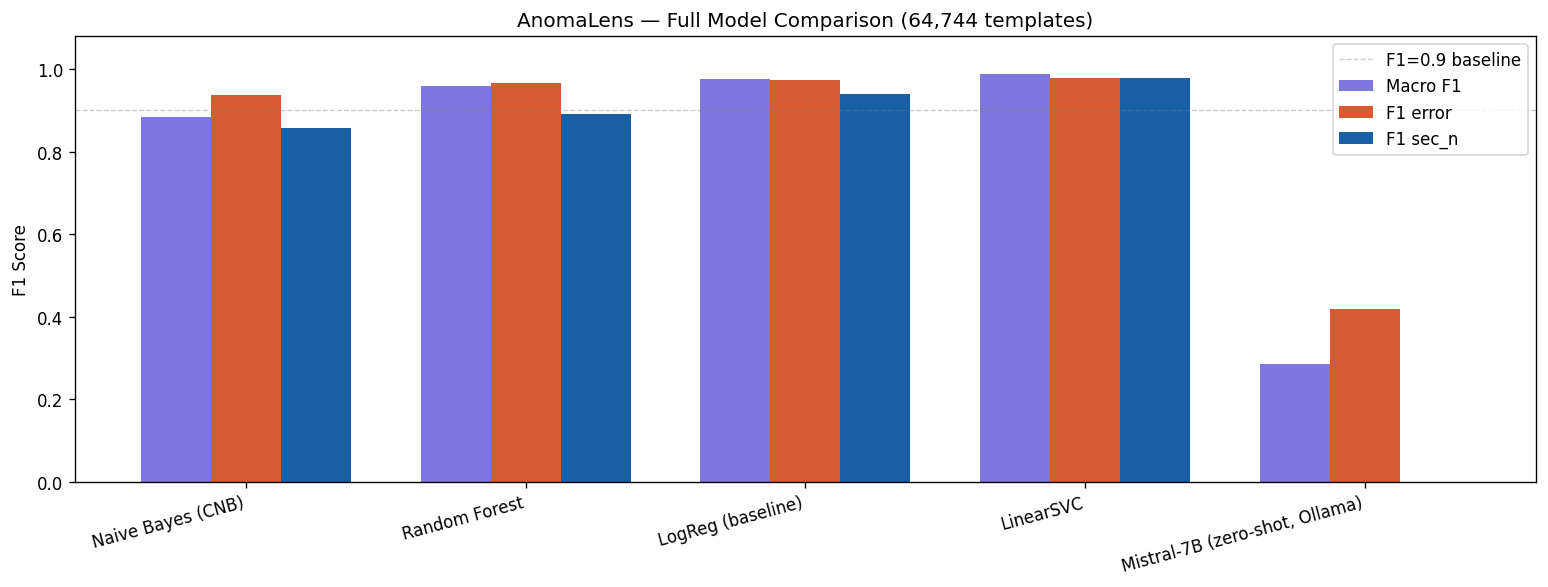

In [28]:
# Load from saved results or use hardcoded final numbers
result_files = sorted(Path('data/results').glob('summary_*.csv'))

if result_files:
    eval_df = pd.read_csv(result_files[-1])
    print(f'Loaded: {result_files[-1].name}')
else:
    eval_df = pd.DataFrame([
        {'Model':'Naive Bayes (CNB)',   'Macro F1':0.884,'F1 error':0.938,'F1 sec_n':0.858,'Accuracy':0.917},
        {'Model':'Random Forest',       'Macro F1':0.959,'F1 error':0.966,'F1 sec_n':0.891,'Accuracy':0.986},
        {'Model':'LogReg (baseline)',   'Macro F1':0.975,'F1 error':0.973,'F1 sec_n':0.939,'Accuracy':0.991},
        {'Model':'LinearSVC',           'Macro F1':0.987,'F1 error':0.978,'F1 sec_n':0.978,'Accuracy':0.994},
        {'Model':'BERT-base (fine-tuned)','Macro F1':0.957,'F1 error':0.972,'F1 sec_n':0.988,'Accuracy':0.957},
        {'Model':'Mistral-7B (zero-shot)','Macro F1':0.535,'F1 error':0.857,'F1 sec_n':0.000,'Accuracy':0.571},
    ])

print(eval_df[['Model','Accuracy','Macro F1','F1 error','F1 sec_n']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(eval_df))
w = 0.25
ax.bar(x - w, eval_df['Macro F1'], w, label='Macro F1',  color='#7F77DD')
ax.bar(x,     eval_df['F1 error'], w, label='F1 error',  color='#D85A30')
ax.bar(x + w, eval_df['F1 sec_n'], w, label='F1 sec_n',  color='#185FA5')
ax.set_xticks(x)
ax.set_xticklabels(eval_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1 Score')
ax.set_title('AnomaLens — Full Model Comparison (64,744 templates)')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.4, label='F1=0.9 baseline')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Component | Technology | Key Result |
|---|---|---|
| Dataset | 64,744 templates, 4 classes | ESXi + Hyper-V via Graylog |
| Normalization | Custom regex | `<HOST>`, `<IP>`, `<NUM>`, `<UUID>` |
| Best classifier | TF-IDF + LinearSVC | **Macro F1 = 0.987** |
| OOD detection | Softmax confidence < 0.45 | ~2.3% flagged as anomaly |
| RAG search | all-MiniLM-L6-v2 + Qdrant | cosine similarity 0.46–0.53 |
| RAG explanation | Phi-3.5-Mini via Ollama | ~6s/item on CPU |
| Daily summary | Mistral-7B via Ollama | every 12 hours |
| BERT baseline | bert-base-uncased fine-tuned | Macro F1 = 0.957, sec_noise = **0.988** |
| Mistral zero-shot | Mistral-7B-Instruct | Macro F1 = 0.535 |

**Key finding:** LinearSVC outperforms BERT overall (0.987 vs 0.957) at 500× inference speed.  
BERT wins only on `security_noise` (F1 = 0.988 vs 0.978).  
Mistral-7B zero-shot (F1 = 0.535) confirms that domain-specific training is essential.